In [202]:
!kaggle datasets download -d wordsforthewise/lending-club \
  -f accepted_2007_to_2018Q4.csv.gz

print("✅ Download done!")

Dataset URL: https://www.kaggle.com/datasets/wordsforthewise/lending-club
License(s): CC0-1.0
accepted_2007_to_2018Q4.csv.gz: Skipping, found more recently modified local copy (use --force to force download)
✅ Download done!


In [203]:
import pandas as pd

# Load the compressed file directly — no unzipping needed
df = pd.read_csv('accepted_2007_to_2018Q4.csv.gz',
                  compression='gzip',
                  low_memory=False,
                  nrows=200000)  # ← changed to 200k

print("✅ Data loaded!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

✅ Data loaded!
Shape: (200000, 151)
Columns: ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', '

In [204]:
df.dtypes.value_counts()
#counts how many columns are of each data type in your DataFrame.

,count
float64,114
object,36
int64,1


In [205]:
df['loan_status'].value_counts()
#This is our target column — it tells us if a loan defaulted or not.

,count
loan_status,
Fully Paid,140992
Charged Off,35090
Current,22637
Late (31-120 days),785
In Grace Period,347
Late (16-30 days),148
Default,1


# **Exploratory data analysis**

In [206]:

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)
df['target'].value_counts()
#This is to check our class imbalance — we'll handle it later with SMOTE.

,count
target,
0,140992
1,35090


In [207]:
#Select relevant columns only
#Some columns can't be used because they only exist after the loan is given:
cols = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate',
    'installment', 'grade', 'sub_grade', 'emp_length',
    'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs', 'fico_range_low',
    'fico_range_high', 'inq_last_6mths', 'open_acc',
    'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'mort_acc', 'pub_rec_bankruptcies', 'target'
]

df = df[cols]
df.shape

(176082, 25)

In [208]:
#This tells us which columns have missing data
# — our next cleaning step depends on this output.

df.isnull().sum().sort_values(ascending=False)

,0
emp_length,11134
revol_util,69
dti,2
loan_amnt,0
funded_amnt,0
installment,0
grade,0
int_rate,0
term,0
home_ownership,0


In [209]:
# Fill emp_length with Unknown
df['emp_length'] = df['emp_length'].fillna('Unknown')

# Fill numerical with median
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())
df['dti'] = df['dti'].fillna(df['dti'].median())
df.isnull().sum().sum()

np.int64(0)

In [210]:
df.dtypes

,0
loan_amnt,float64
funded_amnt,float64
term,object
int_rate,float64
installment,float64
grade,object
sub_grade,object
emp_length,object
home_ownership,object
annual_inc,float64


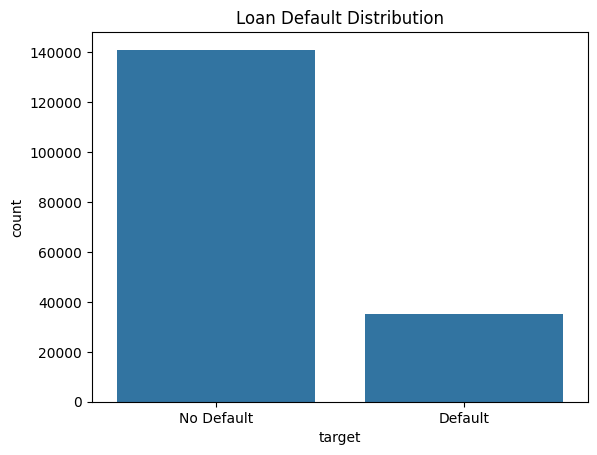

In [211]:
import matplotlib.pyplot as plt   # plotting library
import seaborn as sns
# bar chart of default vs no default
sns.countplot(x='target', data=df)
plt.title('Loan Default Distribution')
plt.xticks([0,1], ['No Default', 'Default'])
plt.show()
#This visually confirms our class imbalance
#— No Default is much larger than Default.

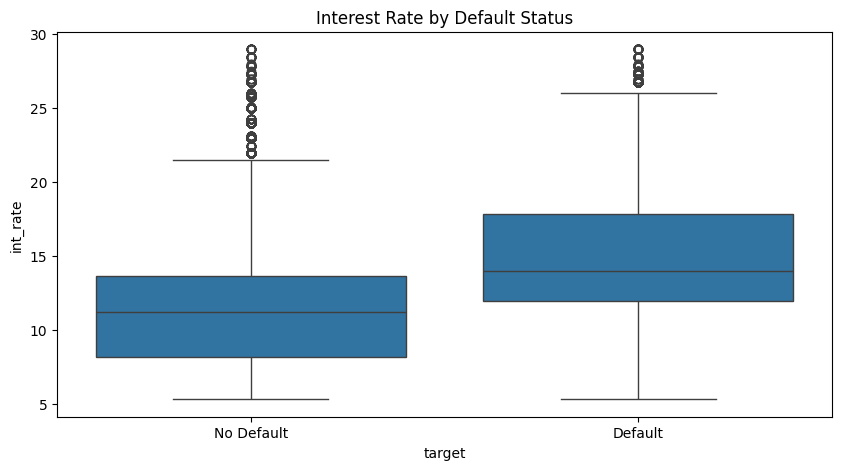

In [212]:
plt.figure(figsize=(10,5))
sns.boxplot(x='target', y='int_rate', data=df) # boxplot shows the DISTRIBUTION of a number column
plt.title('Interest Rate by Default Status')
plt.xticks([0,1], ['No Default', 'Default'])
plt.show()
#inorder to check higher interest rate = more likely to default


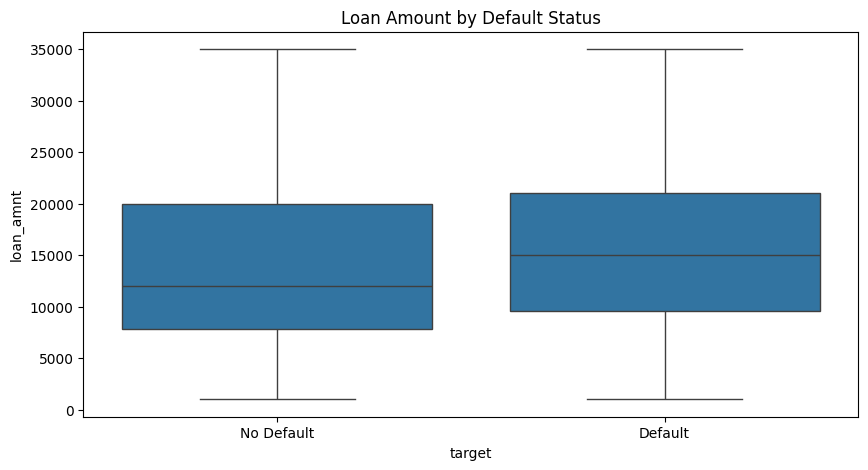

In [213]:
plt.figure(figsize=(10,5))
sns.boxplot(x='target', y='loan_amnt', data=df)
# boxplot comparing loan amount of non defaulter and defaulter
plt.title('Loan Amount by Default Status')
plt.xticks([0,1], ['No Default', 'Default'])
plt.show()


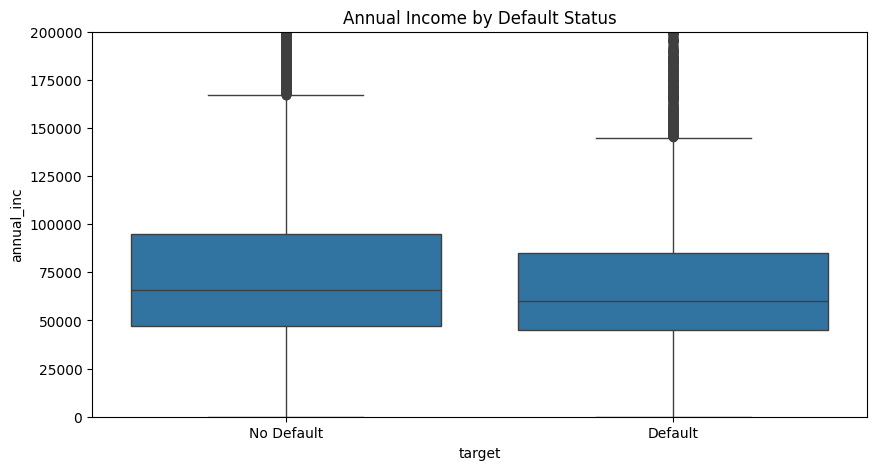

In [214]:
plt.figure(figsize=(10,5))
sns.boxplot(x='target', y='annual_inc', data=df)
# boxplot comparing annual income
plt.title('Annual Income by Default Status')
plt.ylim(0, 200000)
plt.xticks([0,1], ['No Default', 'Default'])
plt.show()
#If Default box is LOWER → lower income = more defaults


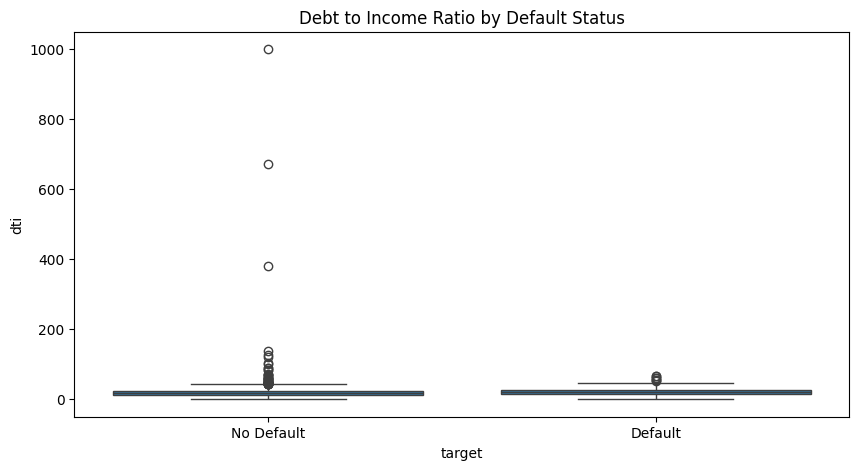

In [215]:
plt.figure(figsize=(10,5))
sns.boxplot(x='target', y='dti', data=df)
# boxplot comparing DTI ratio
plt.title('Debt to Income Ratio by Default Status')
plt.xticks([0,1], ['No Default', 'Default'])
plt.show()
#Because of these extreme outliers (1000, 670, 380)
#the chart zoomed out so much that the actual


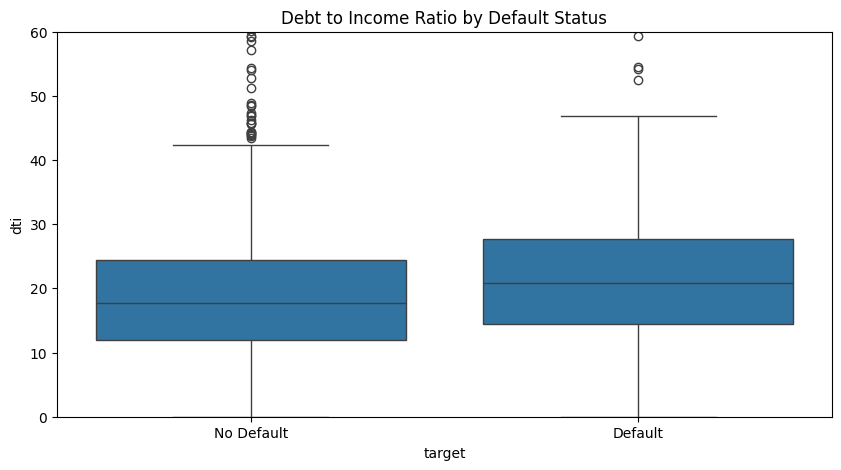

In [216]:
plt.figure(figsize=(10,5))
sns.boxplot(x='target', y='dti', data=df)

plt.title('Debt to Income Ratio by Default Status')
plt.ylim(0, 60)
# THIS IS THE FIX!
# limits y axis from 0 to 60 only
plt.xticks([0,1], ['No Default', 'Default'])
plt.show()


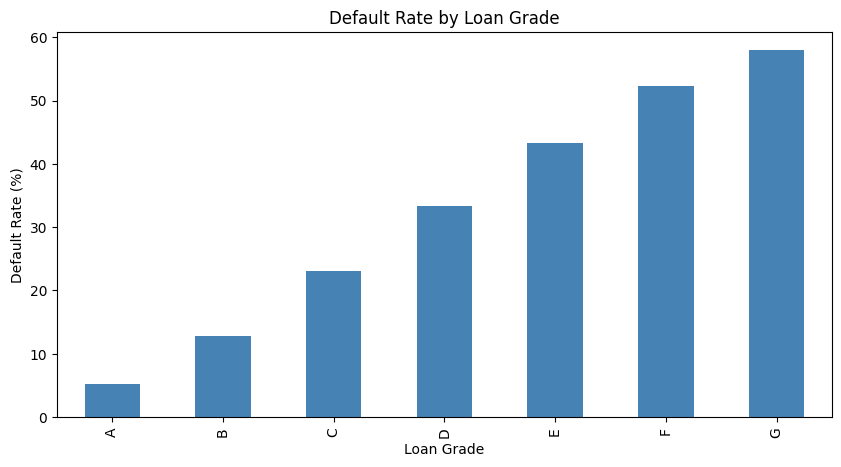

In [217]:
plt.figure(figsize=(10,5))
default_rate = df.groupby('grade')['target'].mean() * 100
# groupby('grade') = group all rows by their grade (A,B,C,D,E,F,G)
# checking grade wise defaulters
default_rate.plot(kind='bar', color='steelblue')
plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')
plt.show()


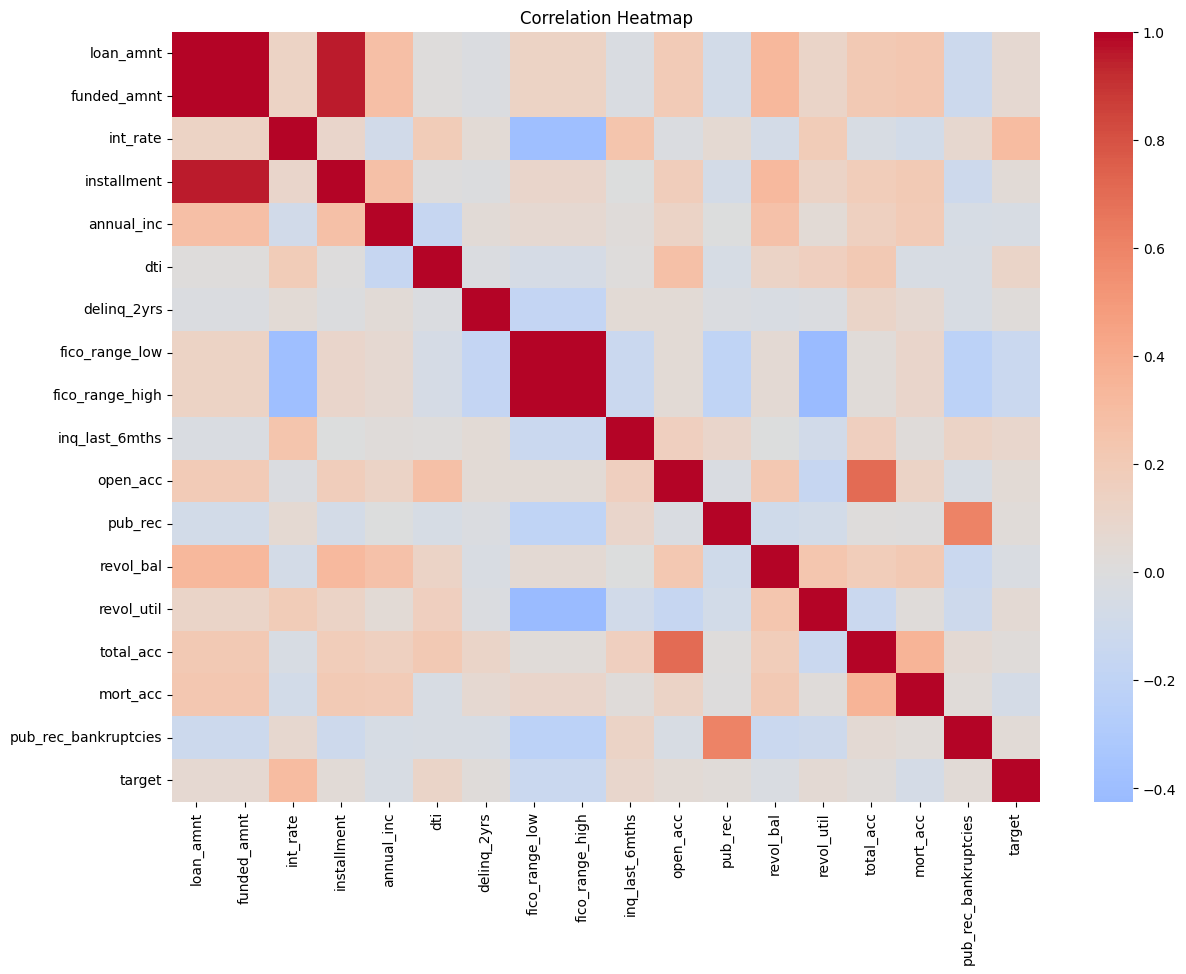

In [218]:
plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include='number')
# select ONLY numerical columns
# removes text columns like grade, purpose etc
correlation = numeric_df.corr()

sns.heatmap(correlation,
            annot=False,
            cmap='coolwarm',
            center=0)
plt.title('Correlation Heatmap')
plt.show()



Positive correlation with target (red):
→ when int_rate goes UP   → defaults go UP   ✅ makes sense
→ when dti goes UP        → defaults go UP   ✅ makes sense

Negative correlation with target (blue):
→ when fico score goes UP → defaults go DOWN ✅ makes sense
→ when annual_inc goes UP → defaults go DOWN ✅ makes sense

# DATA **CLEANING**

In [219]:
df = df.drop(columns=['funded_amnt', 'fico_range_high'])

df.shape

(176082, 23)

In [220]:
import numpy as np
# check DTI before cleaning
print("Before:", df['dti'].max())
df = df[df['dti'] <= 100]
print("After:", df['dti'].max())
df.shape


Before: 999.0
After: 90.0


(176074, 23)

In [221]:
# check unique values in each text column
for col in ['term', 'emp_length', 'home_ownership',
            'verification_status', 'purpose']:


    print(f"\n{col}:")


    print(df[col].unique())
    #Before encoding text columns to numbers — we need to see exactly
    #what values exist in each column so we know how to clean them.



term:
[' 36 months' ' 60 months']

emp_length:
['10+ years' '3 years' '4 years' '6 years' '7 years' '8 years' '2 years'
 '5 years' '9 years' '< 1 year' '1 year' 'Unknown']

home_ownership:
['MORTGAGE' 'RENT' 'OWN' 'ANY']

verification_status:
['Not Verified' 'Source Verified' 'Verified']

purpose:
['debt_consolidation' 'small_business' 'home_improvement' 'major_purchase'
 'credit_card' 'other' 'house' 'vacation' 'car' 'medical' 'moving'
 'renewable_energy' 'wedding']


In [222]:
df['term'] = df['term'].str.strip()

df['term'] = df['term'].str.replace(' months', '')


df['term'] = df['term'].astype(int)


df['term'].unique()


array([36, 60])

In [223]:
df['emp_length'] = df['emp_length'].str.replace(' years', '')
df['emp_length'] = df['emp_length'].str.replace(' year', '')
df['emp_length'] = df['emp_length'].str.replace('< 1', '0')
df['emp_length'] = df['emp_length'].str.replace('+', '')
df['emp_length'] = df['emp_length'].str.replace('Unknown', '0')
df['emp_length'] = df['emp_length'].astype(int)
df['emp_length'].unique()
#clean emplength column

array([10,  3,  4,  6,  7,  8,  2,  5,  9,  0,  1])

In [224]:
df = pd.get_dummies(df,
                    columns=['home_ownership',
                             'verification_status',
                             'purpose'],
                    drop_first=True)
#  Encode Remaining Text Columns
df.shape


(176074, 37)

In [225]:
df.dtypes.value_counts()
#final check

,count
bool,17
float64,15
int64,3
object,2


In [226]:
df.select_dtypes(include='object').columns
#Let's Find Which 2 Columns Are Still Text

Index(['grade', 'sub_grade'], dtype='object')

In [227]:
# Encode Grade and Sub_grade
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
df['grade'] = df['grade'].map(
    {grade: i for i, grade in enumerate(grade_order)})
sub_grades = sorted(df['sub_grade'].unique())
df['sub_grade'] = df['sub_grade'].map(
    {sg: i for i, sg in enumerate(sub_grades)})
print(df['grade'].unique())
print(df['sub_grade'].unique())

[2 1 5 0 4 3 6]
[13 10  8 25 12  6  5  1  9 11 21  3 22 14  0 18 27 15  7 17 19  4 26 23
 16 20 29 24  2 31 30 32 33 28 34]


In [228]:
df.dtypes.value_counts()

,count
bool,17
float64,15
int64,5


# **Feature Engineering**

In [229]:
# creating 3 new columns that combine existing information
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc']
df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12)
df['fico_avg'] = df['fico_range_low']
df.shape


(176074, 40)

# **Preprocessing**

In [230]:

#Use Only fico_range_low
X = df.drop(columns=['target'])
y = df['target']
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Default rate:", y.mean().round(3))


X shape: (176074, 39)
y shape: (176074,)
Default rate: 0.199


In [231]:
#Split Data into Train and Test
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
                    X, y,
                    test_size=0.2,
                    random_state=42,
                    stratify=y)


X_train.shape, X_test.shape


((140859, 39), (35215, 39))

In [232]:
#Check and Clean Infinity Values
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)
X.isnull().sum().sum()


np.int64(4)

In [233]:
# fill NaN values with median of each column
X = X.fillna(X.median())

# verify no infinity or NaN remaining
import numpy as np
print("Infinity values:", np.isinf(X).sum().sum())
print("NaN values:", X.isnull().sum().sum())

Infinity values: 0
NaN values: 0


In [234]:
import numpy as np


inf_cols = X.columns[np.isinf(X).any()]

print("Columns with infinity:", inf_cols)
print("Total infinity values:", np.isinf(X).sum().sum())
print("Total NaN values:", X.isnull().sum().sum())

Columns with infinity: Index([], dtype='object')
Total infinity values: 0
Total NaN values: 0


In [235]:
# convert all columns to float64
X = X.astype('float64')

X.dtypes.value_counts()

,count
float64,39


In [236]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# redo split with clean X
X_train, X_test, y_train, y_test = train_test_split(
                    X, y,
                    test_size=0.2,
                    random_state=42,
                    stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("✅ Scaling done!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

✅ Scaling done!
X_train shape: (140859, 39)
X_test shape: (35215, 39)


In [237]:
#Handle Class Imbalance with SMOTE

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 112787, 1: 28072}
After SMOTE: {0: 112787, 1: 112787}


#**Model Building**

In [238]:
from sklearn.linear_model import LogisticRegression
# import Logistic Regression from sklearn
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_sm, y_train_sm)
print("✅ Logistic Regression trained!")

✅ Logistic Regression trained!


In [239]:
#Classification report with precision,
#recall and f1 scores

from sklearn.metrics import (classification_report,
                              roc_auc_score,
                              confusion_matrix)

y_pred_lr = lr_model.predict(X_test)


print("AUC-ROC:", roc_auc_score(y_test, y_pred_lr).round(3))


print("\n", classification_report(y_test, y_pred_lr))


AUC-ROC: 0.676

               precision    recall  f1-score   support

           0       0.89      0.70      0.78     28197
           1       0.35      0.65      0.46      7018

    accuracy                           0.69     35215
   macro avg       0.62      0.68      0.62     35215
weighted avg       0.78      0.69      0.72     35215



In [240]:
from sklearn.ensemble import RandomForestClassifier
# import Random Forest from sklearn

rf_model = RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1)


rf_model.fit(X_train_sm, y_train_sm)


print("✅ Random Forest trained!")

✅ Random Forest trained!


In [241]:
#Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test)
print("AUC-ROC:", roc_auc_score(y_test, y_pred_rf).round(3))
print("\n", classification_report(y_test, y_pred_rf))


AUC-ROC: 0.591

               precision    recall  f1-score   support

           0       0.83      0.94      0.88     28197
           1       0.50      0.24      0.33      7018

    accuracy                           0.80     35215
   macro avg       0.67      0.59      0.61     35215
weighted avg       0.77      0.80      0.77     35215



In [242]:
from xgboost import XGBClassifier
# import XGBoost classifier

xgb_model = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42,
            n_jobs=-1,
            eval_metric='logloss',
            verbosity=0)


xgb_model.fit(X_train_sm, y_train_sm)

print("✅ XGBoost trained!")

✅ XGBoost trained!


In [243]:
#Evaluate XGBoost
y_pred_xgb = xgb_model.predict(X_test)
print("AUC-ROC:", roc_auc_score(y_test, y_pred_xgb).round(3))

print("\n", classification_report(y_test, y_pred_xgb))


AUC-ROC: 0.598

               precision    recall  f1-score   support

           0       0.84      0.94      0.88     28197
           1       0.52      0.26      0.34      7018

    accuracy                           0.80     35215
   macro avg       0.68      0.60      0.61     35215
weighted avg       0.77      0.80      0.78     35215



In [244]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Step 1 — fresh split
X_train, X_test, y_train, y_test = train_test_split(
                    X, y,
                    test_size=0.2,
                    random_state=42,
                    stratify=y)

# Step 2 — scale AFTER split
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3 — apply SMOTE on scaled training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(
                          X_train_scaled, y_train)

print("✅ Pipeline fixed!")
print("X_train_sm shape:", X_train_sm.shape)
print("y_train_sm value counts:")
print(y_train_sm.value_counts())

✅ Pipeline fixed!
X_train_sm shape: (225574, 39)
y_train_sm value counts:
target
0    112787
1    112787
Name: count, dtype: int64


In [245]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model 1 — Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_sm, y_train_sm)
print("✅ Logistic Regression trained!")

# Model 2 — Random Forest
rf_model = RandomForestClassifier(n_estimators=100,
                                   random_state=42,
                                   n_jobs=-1)
rf_model.fit(X_train_sm, y_train_sm)
print("✅ Random Forest trained!")

# Model 3 — XGBoost
xgb_model = XGBClassifier(n_estimators=100,
                           learning_rate=0.1,
                           max_depth=5,
                           random_state=42,
                           n_jobs=-1,
                           eval_metric='logloss',
                           verbosity=0)
xgb_model.fit(X_train_sm, y_train_sm)
print("✅ XGBoost trained!")

✅ Logistic Regression trained!
✅ Random Forest trained!
✅ XGBoost trained!


In [246]:
from sklearn.metrics import classification_report, roc_auc_score

# evaluate all 3 models on CORRECT test data
models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}


for name, model in models.items():


    y_pred = model.predict(X_test_scaled)


    auc = roc_auc_score(y_test, y_pred).round(3)


    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"AUC-ROC: {auc}")
    print(classification_report(y_test, y_pred))
    # print full report for each model


Model: Logistic Regression
AUC-ROC: 0.676
              precision    recall  f1-score   support

           0       0.89      0.70      0.78     28197
           1       0.35      0.65      0.46      7018

    accuracy                           0.69     35215
   macro avg       0.62      0.68      0.62     35215
weighted avg       0.78      0.69      0.72     35215


Model: Random Forest
AUC-ROC: 0.591
              precision    recall  f1-score   support

           0       0.83      0.94      0.88     28197
           1       0.50      0.24      0.33      7018

    accuracy                           0.80     35215
   macro avg       0.67      0.59      0.61     35215
weighted avg       0.77      0.80      0.77     35215


Model: XGBoost
AUC-ROC: 0.598
              precision    recall  f1-score   support

           0       0.84      0.94      0.88     28197
           1       0.52      0.26      0.34      7018

    accuracy                           0.80     35215
   macro avg     

In [247]:
#  Retrain XGBoost With class Weight

scale = len(y_train[y_train==0]) / len(y_train[y_train==1])


print("scale_pos_weight:", round(scale, 2))

xgb_model2 = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42,
            n_jobs=-1,
            eval_metric='logloss',
            verbosity=0,
            scale_pos_weight=scale)


xgb_model2.fit(X_train_scaled, y_train)


y_pred_xgb2 = xgb_model2.predict(X_test_scaled)

print("AUC-ROC:", roc_auc_score(y_test, y_pred_xgb2).round(3))
print(classification_report(y_test, y_pred_xgb2))

scale_pos_weight: 4.02
AUC-ROC: 0.681
              precision    recall  f1-score   support

           0       0.89      0.69      0.78     28197
           1       0.35      0.68      0.46      7018

    accuracy                           0.69     35215
   macro avg       0.62      0.68      0.62     35215
weighted avg       0.79      0.69      0.71     35215



In [248]:
#Find Balanced Threshold
import numpy as np
from sklearn.metrics import precision_recall_curve


y_prob = xgb_model2.predict_proba(X_test_scaled)[:,1]


precisions, recalls, thresholds = precision_recall_curve(
                                    y_test, y_prob)


f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / \
            (precisions[:-1] + recalls[:-1] + 1e-10)



best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", round(best_threshold, 3))
print("Best F1 score:", round(best_f1, 3))


y_pred_tuned = (y_prob >= best_threshold).astype(int)

print("\nAUC-ROC:", roc_auc_score(y_test, y_pred_tuned).round(3))
print(classification_report(y_test, y_pred_tuned))

Best threshold: 0.554
Best F1 score: 0.466

AUC-ROC: 0.677
              precision    recall  f1-score   support

           0       0.88      0.77      0.82     28197
           1       0.39      0.58      0.47      7018

    accuracy                           0.73     35215
   macro avg       0.63      0.68      0.64     35215
weighted avg       0.78      0.73      0.75     35215



#**Hyperparameter Tuning With Optuna**

In [249]:
!pip install optuna -q


import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


print("✅ Optuna installed!")

✅ Optuna installed!


In [250]:
#Optuna tunning

from sklearn.metrics import roc_auc_score
import optuna

def objective(trial):


    params = {
        'n_estimators': trial.suggest_int(
                        'n_estimators', 50, 300),


        'learning_rate': trial.suggest_float(
                        'learning_rate', 0.01, 0.3),


        'max_depth': trial.suggest_int(
                        'max_depth', 3, 9),


        'subsample': trial.suggest_float(
                        'subsample', 0.6, 1.0),


        'colsample_bytree': trial.suggest_float(
                        'colsample_bytree', 0.6, 1.0),


        'scale_pos_weight': scale,


        'random_state': 42,
        'eval_metric': 'logloss',
        'verbosity': 0
    }

    model = XGBClassifier(**params)


    model.fit(X_train_scaled, y_train)


    y_pred = model.predict(X_test_scaled)


    return roc_auc_score(y_test, y_pred)



study = optuna.create_study(direction='maximize')


study.optimize(objective, n_trials=50)


print("✅ Tuning done!")
print("Best AUC-ROC:", round(study.best_value, 3))
print("Best Parameters:", study.best_params)

✅ Tuning done!
Best AUC-ROC: 0.682
Best Parameters: {'n_estimators': 130, 'learning_rate': 0.288882660258408, 'max_depth': 3, 'subsample': 0.9245723719261622, 'colsample_bytree': 0.8834110849162308}


In [251]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# train final model with best optuna parameters
best_model = XGBClassifier(
            n_estimators=74,
            learning_rate=0.03445434096530499,
            max_depth=6,
            subsample=0.647277446634337,
            colsample_bytree=0.7591069423669108,
            scale_pos_weight=scale,
            random_state=42,
            eval_metric='logloss',
            verbosity=0)

best_model.fit(X_train_scaled, y_train)


y_pred_final = best_model.predict(X_test_scaled)


y_prob_final = best_model.predict_proba(X_test_scaled)[:,1]


print("✅ Final model trained!")
print("AUC-ROC:", roc_auc_score(y_test, y_prob_final).round(3))


✅ Final model trained!
AUC-ROC: 0.743


In [252]:
from sklearn.metrics import classification_report

print("=" * 50)
print("FINAL MODEL — FULL EVALUATION REPORT")
print("=" * 50)


print("\nAUC-ROC:", roc_auc_score(
        y_test, y_prob_final).round(3))


print("\n", classification_report(
        y_test, y_pred_final,
        target_names=['No Default', 'Default']))


FINAL MODEL — FULL EVALUATION REPORT

AUC-ROC: 0.743

               precision    recall  f1-score   support

  No Default       0.89      0.68      0.77     28197
     Default       0.34      0.68      0.45      7018

    accuracy                           0.68     35215
   macro avg       0.62      0.68      0.61     35215
weighted avg       0.78      0.68      0.71     35215



# **Evaluation**

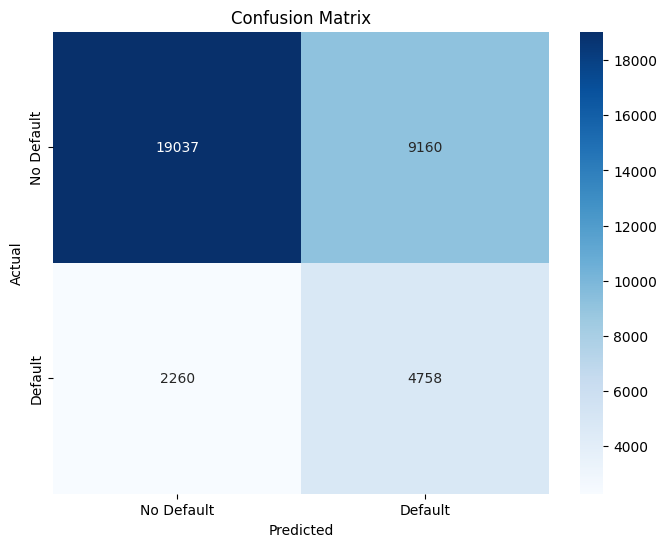

In [253]:
#confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)


plt.figure(figsize=(8,6))


sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])

plt.title('Confusion Matrix')


plt.ylabel('Actual')


plt.xlabel('Predicted')


plt.show()


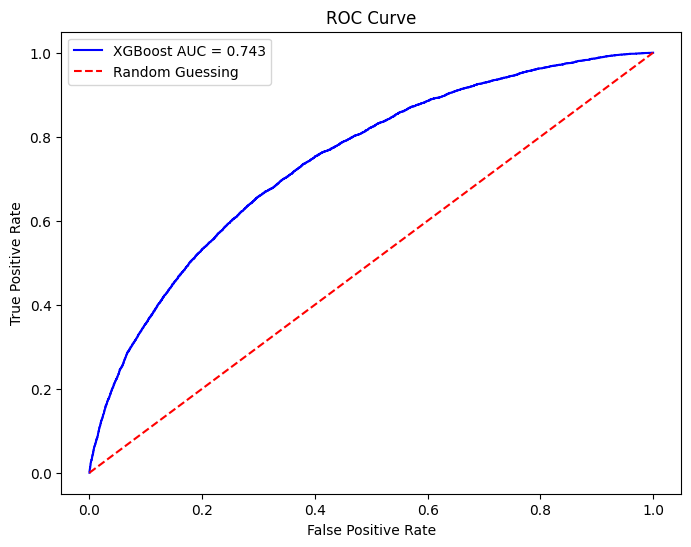

In [254]:
#ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)


auc_score = roc_auc_score(y_test, y_prob_final).round(3)


plt.figure(figsize=(8,6))


plt.plot(fpr, tpr,
         color='blue',
         label=f'XGBoost AUC = {auc_score}')


plt.plot([0,1], [0,1],
         color='red',
         linestyle='--',
         label='Random Guessing')


plt.title('ROC Curve')


plt.xlabel('False Positive Rate')


plt.ylabel('True Positive Rate')


plt.legend()


plt.show()


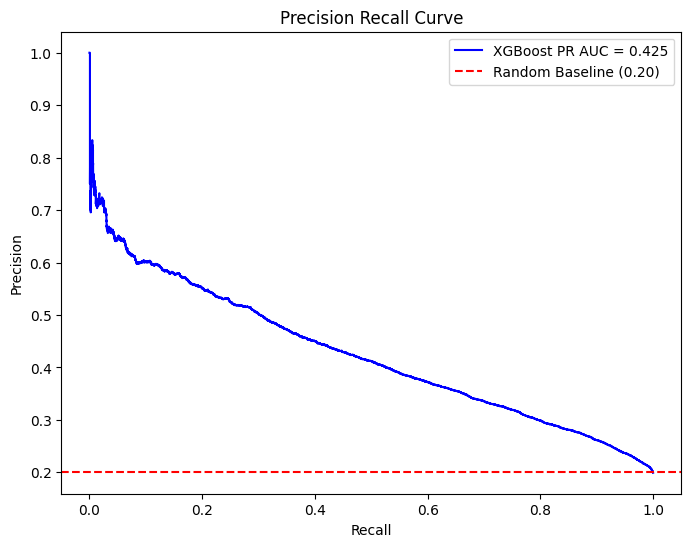

In [255]:
# calculates precision and recall

from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(
                                    y_test, y_prob_final)

pr_auc = auc(recall, precision).round(3)


plt.figure(figsize=(8,6))


plt.plot(recall, precision,
         color='blue',
         label=f'XGBoost PR AUC = {pr_auc}')


plt.axhline(y=0.20,
            color='red',
            linestyle='--',
            label='Random Baseline (0.20)')


plt.title('Precision Recall Curve')


plt.xlabel('Recall')


plt.ylabel('Precision')

plt.legend()


plt.show()


# ** SHAP Explainability**

In [256]:
!pip install shap -q
# installs shap library
# -q = quiet mode

import shap
# imports shap library

print("✅ SHAP installed!")

✅ SHAP installed!


In [257]:
#Create SHAP Explainer

explainer = shap.TreeExplainer(best_model)


shap_values = explainer.shap_values(X_test_scaled)


print("✅ SHAP values calculated!")
print("Shape:", shap_values.shape)


✅ SHAP values calculated!
Shape: (35215, 39)


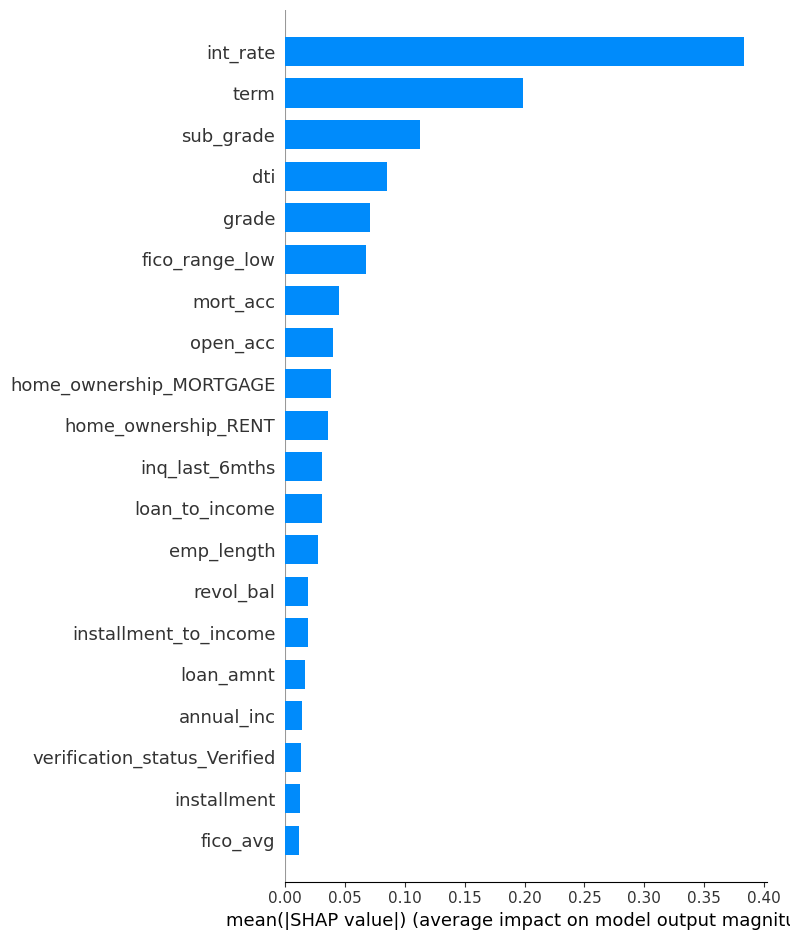

In [258]:
# SHAP Summary Plot

plt.figure(figsize=(10,8))

feature_names = list(X.columns)

shap.summary_plot(shap_values,
                  X_test_scaled,
                  feature_names=feature_names,
                  plot_type='bar',
                  show=True)


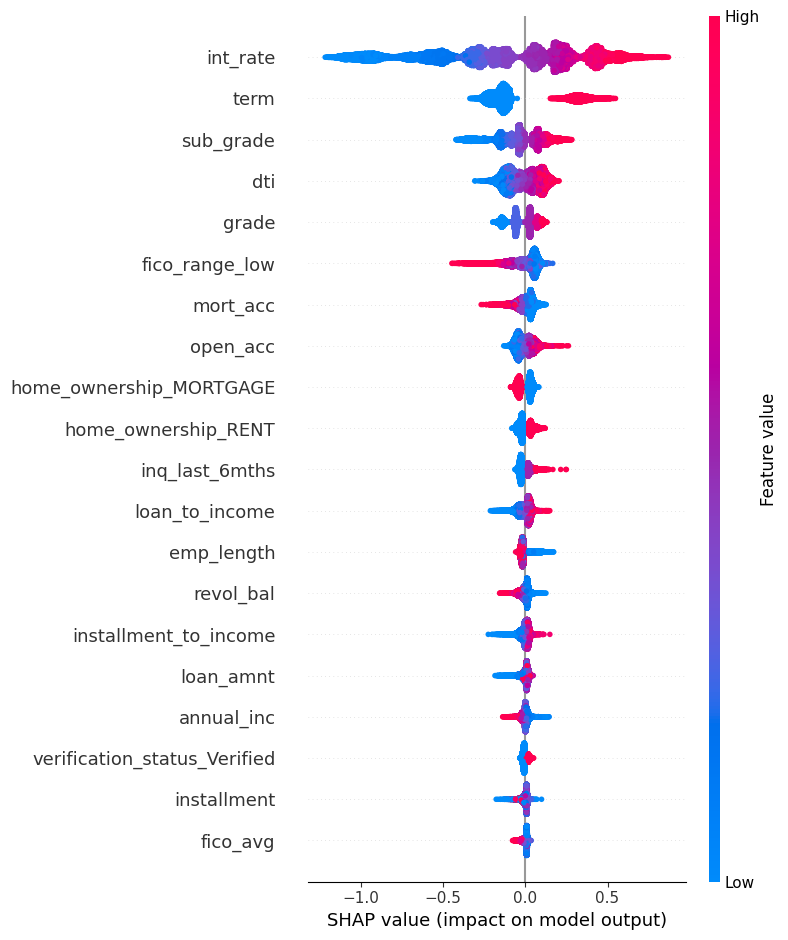

In [259]:
plt.figure(figsize=(10,8))
# SHAP Dot Plot — Direction of Features

shap.summary_plot(shap_values,
                  X_test_scaled,
                  feature_names=feature_names,
                  plot_type='dot',
                  show=True)


In [260]:
#Save Model and Scaler
import pickle


with open('loan_default_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)


with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)



with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)


print("✅ Model saved!")
print("✅ Scaler saved!")
print("✅ Feature names saved!")

✅ Model saved!
✅ Scaler saved!
✅ Feature names saved!


In [261]:
from google.colab import files

# download all 3 files to your laptop
files.download('loan_default_model.pkl')
files.download('scaler.pkl')
files.download('feature_names.pkl')

print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
